# TASK 2: Image Data Collection, Processing & Facial Recognition Model

**Goal:** Collect facial images per group member, apply augmentations, extract features, and build a facial recognition model.

**Pipeline:**
1. Image Collection (3 expressions per member: neutral, smiling, surprised)
2. Display & Inspect Images
3. Augmentation (rotation, flipping, grayscale)
4. Feature Extraction (histograms + HOG embeddings)
5. Save `image_features.csv`
6. Train & Evaluate Facial Recognition Model

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image, ImageDraw, ImageFont, ImageFilter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, log_loss
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Ensure working directory is the project root (not notebooks/)
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Working directory: {os.getcwd()}")

plt.style.use('seaborn-v0_8-darkgrid')
print("Libraries loaded successfully")

Working directory: C:\Users\josue\Music\ml-pipeline-formative-2
Libraries loaded successfully


## 1. Image Collection Structure

Each group member submits 3 facial images with different expressions:
- **Neutral** — relaxed face
- **Smiling** — happy expression
- **Surprised** — wide eyes / open mouth

**Group Members:**
| Member ID | Name | Images |
|-----------|------|--------|
| 1 | Josue | neutral, smiling, surprised |
| 2 | Bonaparte | neutral (serious), smiling, surprised (amazed) |
| 3 | Yunis | neutral (serious), smiling, surprised |
| 4 | Preye | neutral, smiling, surprised |

**Naming convention:** `member{N}_{expression}.jpg`

**Directory layout:**
```
data/images/
├── member1/   (Josue)
├── member2/   (Bonaparte)
├── member3/   (Yunis)
├── member4/   (Preye)
└── augmented/  (all augmented outputs)
```

In [2]:
# All members have real facial images — no synthetic generation needed
# Images were collected from each group member and placed in:
#   data/images/member{N}/member{N}_{expression}.jpg

expressions = ['neutral', 'smiling', 'surprised']
members = [1, 2, 3, 4]
member_names = {1: 'Josue', 2: 'Bonaparte', 3: 'Yunis', 4: 'Preye'}
image_dir = 'data/images'

# Verify all images exist
missing = []
for member in members:
    for expr in expressions:
        filepath = os.path.join(image_dir, f'member{member}', f'member{member}_{expr}.jpg')
        if not os.path.exists(filepath):
            missing.append(filepath)

if missing:
    print("WARNING - Missing images:")
    for f in missing:
        print(f"  {f}")
else:
    print(f"All {len(members) * len(expressions)} member images verified:")
    for member in members:
        sizes = []
        for expr in expressions:
            fp = os.path.join(image_dir, f'member{member}', f'member{member}_{expr}.jpg')
            size_kb = os.path.getsize(fp) / 1024
            sizes.append(f"{expr} ({size_kb:.0f}KB)")
        print(f"  Member {member} ({member_names[member]}): {', '.join(sizes)}")

All 12 member images verified:
  Member 1 (Josue): neutral (105KB), smiling (108KB), surprised (106KB)
  Member 2 (Bonaparte): neutral (267KB), smiling (260KB), surprised (262KB)
  Member 3 (Yunis): neutral (97KB), smiling (99KB), surprised (98KB)
  Member 4 (Preye): neutral (1649KB), smiling (2184KB), surprised (3806KB)


## 2. Load & Display Sample Images

Display all group members' facial images in a grid layout with labels showing member name and expression.

Josue (Member 1): 1280x720px, 3 channels, dtype=uint8
Bonaparte (Member 2): 2520x1680px, 3 channels, dtype=uint8


Yunis (Member 3): 1200x1600px, 3 channels, dtype=uint8


Preye (Member 4): 2736x3648px, 3 channels, dtype=uint8


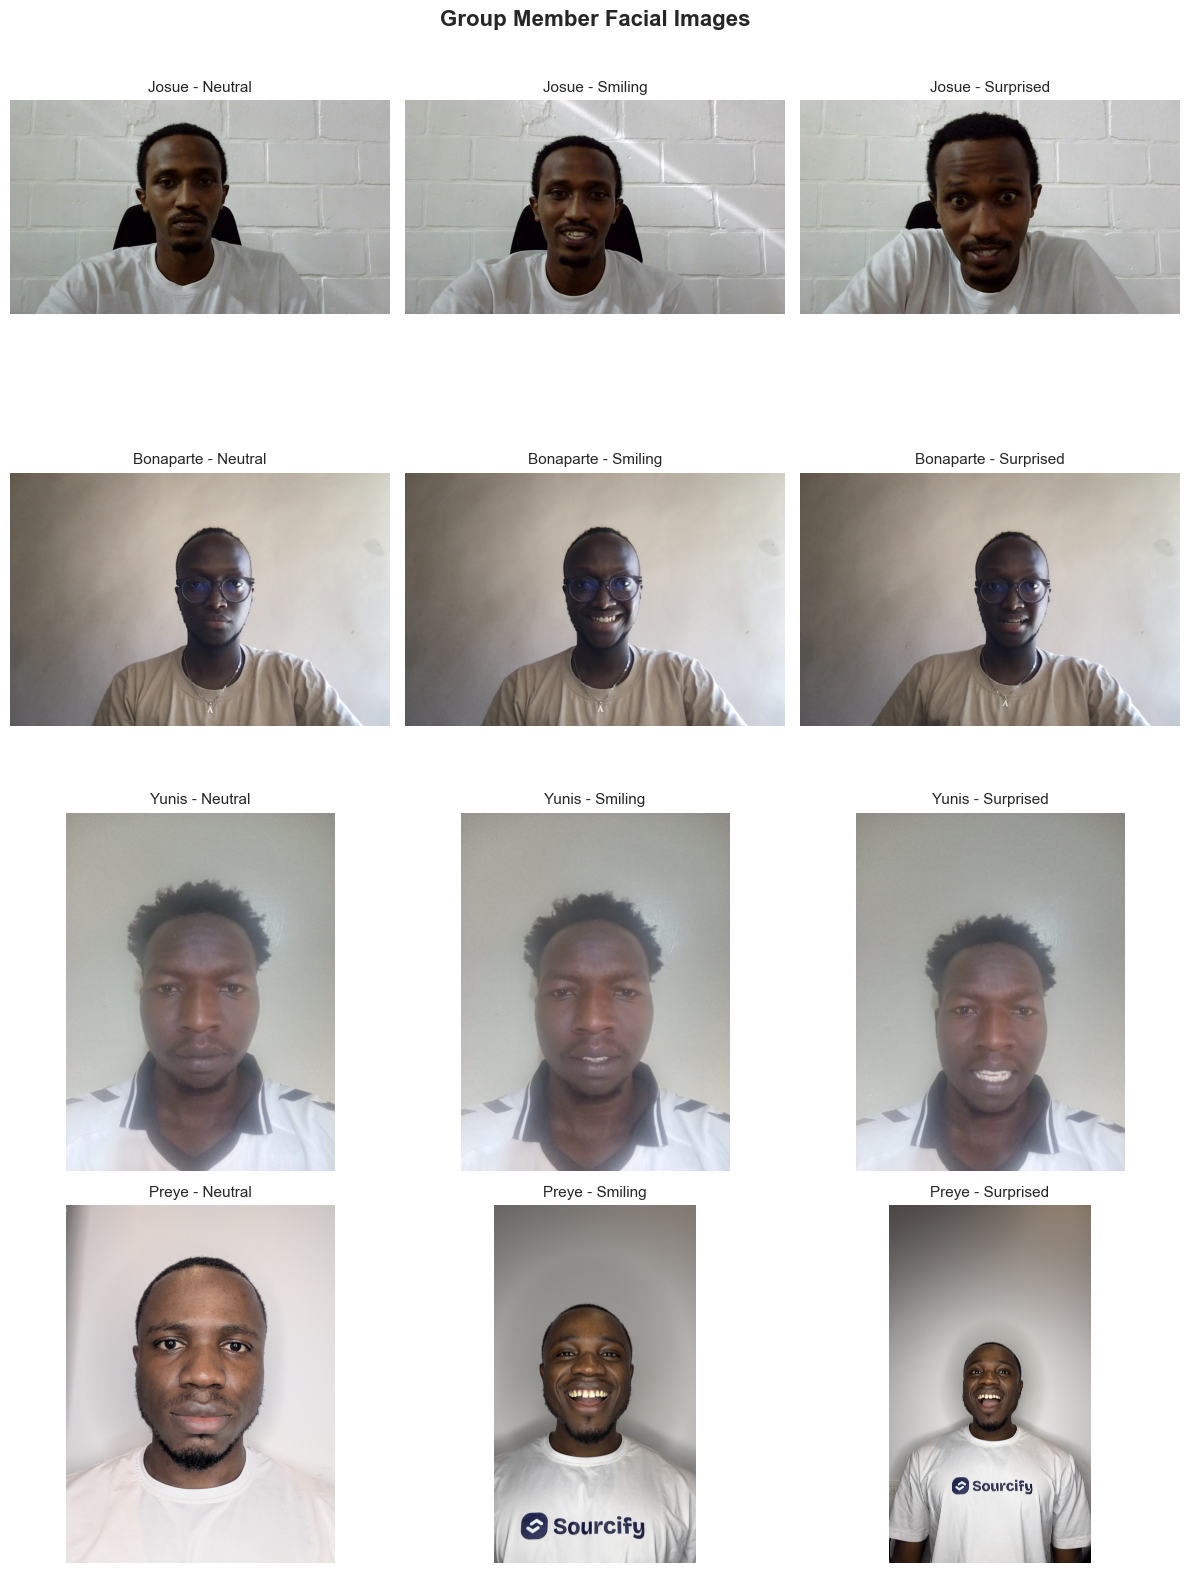


Total images loaded: 12


In [3]:
# Load and display all member images in a grid
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Group Member Facial Images', fontsize=16, fontweight='bold')

for i, member in enumerate(members):
    for j, expr in enumerate(expressions):
        filepath = os.path.join(image_dir, f'member{member}', f'member{member}_{expr}.jpg')
        img = cv2.imread(filepath)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        axes[i, j].imshow(img_rgb)
        axes[i, j].set_title(f'{member_names[member]} - {expr.capitalize()}', fontsize=11)
        axes[i, j].axis('off')
        
        # Print image info for first expression of each member
        if j == 0:
            h, w, c = img.shape
            print(f"{member_names[member]} (Member {member}): {w}x{h}px, {c} channels, dtype={img.dtype}")

plt.tight_layout()
plt.savefig('outputs/member_images_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nTotal images loaded: {len(members) * len(expressions)}")

## 3. Image Augmentation

We apply **3 augmentations** per image to increase dataset diversity and model robustness:

1. **Rotation** — Rotate by +15 and -15 degrees (simulates head tilt)
2. **Horizontal Flip** — Mirror the image (simulates camera angle variation)
3. **Grayscale** — Convert to grayscale (simulates lighting variation)

This ensures **at least 2 augmentations per image** as required by the rubric.

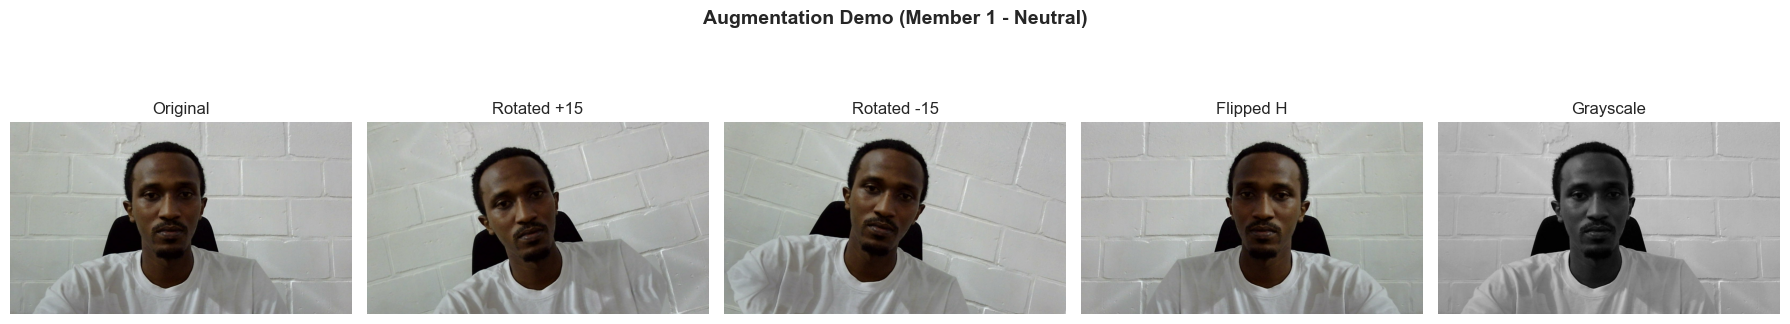

Augmentation functions defined and demonstrated


In [4]:
def rotate_image(img, angle):
    """Rotate image by given angle (degrees) with border padding."""
    h, w = img.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)
    return rotated

def flip_image(img, direction='horizontal'):
    """Flip image horizontally (mirror) or vertically."""
    if direction == 'horizontal':
        return cv2.flip(img, 1)
    return cv2.flip(img, 0)

def to_grayscale(img):
    """Convert to grayscale and back to 3-channel for consistency."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Demonstrate augmentations on one sample image
sample_path = os.path.join(image_dir, 'member1', 'member1_neutral.jpg')
sample_img = cv2.imread(sample_path)
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

augmentations = {
    'Original': sample_rgb,
    'Rotated +15': cv2.cvtColor(rotate_image(sample_img, 15), cv2.COLOR_BGR2RGB),
    'Rotated -15': cv2.cvtColor(rotate_image(sample_img, -15), cv2.COLOR_BGR2RGB),
    'Flipped H': cv2.cvtColor(flip_image(sample_img, 'horizontal'), cv2.COLOR_BGR2RGB),
    'Grayscale': cv2.cvtColor(to_grayscale(sample_img), cv2.COLOR_BGR2RGB),
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Augmentation Demo (Member 1 - Neutral)', fontsize=14, fontweight='bold')
for ax, (title, aug_img) in zip(axes, augmentations.items()):
    ax.imshow(aug_img)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmentation functions defined and demonstrated")

### 3.1 Apply Augmentation Pipeline to All Images

For each member's 3 images, we apply rotation (+15), horizontal flip, and grayscale — producing 3 augmented versions per original image (36 augmented + 12 original = 48 total images).

In [5]:
augmented_dir = os.path.join(image_dir, 'augmented')
os.makedirs(augmented_dir, exist_ok=True)

# Track all images (original + augmented) with metadata
all_images = []

augmentation_pipeline = [
    ('rotated_15', lambda img: rotate_image(img, 15)),
    ('flipped', lambda img: flip_image(img, 'horizontal')),
    ('grayscale', lambda img: to_grayscale(img)),
]

for member in members:
    member_dir = os.path.join(image_dir, f'member{member}')
    for expr in expressions:
        # Original image
        orig_path = os.path.join(member_dir, f'member{member}_{expr}.jpg')
        img = cv2.imread(orig_path)
        all_images.append({
            'member_id': member,
            'expression': expr,
            'image_path': orig_path,
            'augmentation': 'original',
            'is_augmented': False
        })
        
        # Apply each augmentation
        for aug_name, aug_func in augmentation_pipeline:
            aug_img = aug_func(img)
            aug_filename = f'member{member}_{expr}_{aug_name}.jpg'
            aug_path = os.path.join(augmented_dir, aug_filename)
            cv2.imwrite(aug_path, aug_img)
            all_images.append({
                'member_id': member,
                'expression': expr,
                'image_path': aug_path,
                'augmentation': aug_name,
                'is_augmented': True
            })

image_catalog = pd.DataFrame(all_images)
print(f"Total images in catalog: {len(image_catalog)}")
print(f"  Original: {(~image_catalog['is_augmented']).sum()}")
print(f"  Augmented: {image_catalog['is_augmented'].sum()}")
print(f"\nAugmentation breakdown:")
print(image_catalog['augmentation'].value_counts())
print(f"\nImages per member:")
print(image_catalog.groupby('member_id').size())

Total images in catalog: 48
  Original: 12
  Augmented: 36

Augmentation breakdown:
augmentation
original      12
rotated_15    12
flipped       12
grayscale     12
Name: count, dtype: int64

Images per member:
member_id
1    12
2    12
3    12
4    12
dtype: int64


## 4. Feature Extraction

We extract two types of features from each image:

### 4.1 Color Histograms
- Compute RGB color histograms (32 bins per channel = 96 features)
- Captures the overall color distribution of each face

### 4.2 HOG (Histogram of Oriented Gradients) Embeddings
- Extracts edge and texture patterns from grayscale images
- Captures facial structure (eyes, nose, mouth shapes)
- Resized to 64x64 for consistent feature length

In [6]:
def extract_color_histogram(img, bins=32):
    """Extract flattened RGB color histogram features."""
    features = []
    for channel in range(3):  # B, G, R
        hist = cv2.calcHist([img], [channel], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.extend(hist)
    return features  # 32 * 3 = 96 features

def extract_hog_features(img, target_size=(64, 64)):
    """Extract HOG (Histogram of Oriented Gradients) features."""
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, target_size)
    
    # HOG parameters
    win_size = target_size
    block_size = (16, 16)
    block_stride = (8, 8)
    cell_size = (8, 8)
    n_bins = 9
    
    hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, n_bins)
    features = hog.compute(resized)
    return features.flatten()

# Test on a sample image
sample_img = cv2.imread(os.path.join(image_dir, 'member1', 'member1_neutral.jpg'))
hist_features = extract_color_histogram(sample_img)
hog_features = extract_hog_features(sample_img)

print(f"Color histogram features: {len(hist_features)}")
print(f"HOG features: {len(hog_features)}")
print(f"Total features per image: {len(hist_features) + len(hog_features)}")

Color histogram features: 96
HOG features: 1764
Total features per image: 1860


In [7]:
# Extract features from ALL images (original + augmented)
feature_rows = []

for idx, row in image_catalog.iterrows():
    img = cv2.imread(row['image_path'])
    if img is None:
        print(f"Warning: Could not load {row['image_path']}")
        continue
    
    # Extract both feature types
    hist_feats = extract_color_histogram(img)
    hog_feats = extract_hog_features(img)
    
    # Build feature row with metadata
    feat_dict = {
        'member_id': row['member_id'],
        'expression': row['expression'],
        'augmentation': row['augmentation'],
        'is_augmented': row['is_augmented'],
        'image_path': row['image_path'],
    }
    
    # Add histogram features
    for i, val in enumerate(hist_feats):
        feat_dict[f'hist_{i}'] = val
    
    # Add HOG features
    for i, val in enumerate(hog_feats):
        feat_dict[f'hog_{i}'] = val
    
    feature_rows.append(feat_dict)

features_df = pd.DataFrame(feature_rows)
print(f"Feature matrix shape: {features_df.shape}")
print(f"Metadata columns: member_id, expression, augmentation, is_augmented, image_path")
print(f"Histogram features: {len(hist_feats)} (hist_0 to hist_{len(hist_feats)-1})")
print(f"HOG features: {len(hog_feats)} (hog_0 to hog_{len(hog_feats)-1})")
print(f"\nSample (first 3 rows, first 10 feature columns):")
feature_cols = [c for c in features_df.columns if c.startswith('hist_') or c.startswith('hog_')]
display(features_df[['member_id', 'expression', 'augmentation'] + feature_cols[:10]].head(3))

Feature matrix shape: (48, 1865)
Metadata columns: member_id, expression, augmentation, is_augmented, image_path
Histogram features: 96 (hist_0 to hist_95)
HOG features: 1764 (hog_0 to hog_1763)

Sample (first 3 rows, first 10 feature columns):


,member_id,expression,augmentation,hist_0,hist_1,hist_2,hist_3,hist_4,hist_5,hist_6,hist_7,hist_8,hist_9
0,1,neutral,original,0.149469,0.081746,0.062290,0.054617,0.041118,0.024697,0.018470,0.015489,0.010415,0.007380
1,1,neutral,rotated_15,0.149038,0.082087,0.062771,0.055342,0.041177,0.024990,0.018324,0.015950,0.010534,0.007393
2,1,neutral,flipped,0.149126,0.082148,0.062133,0.054803,0.041115,0.024831,0.018305,0.015616,0.010352,0.007429


## 5. Save image_features.csv

Save the combined histogram + HOG features with metadata to `data/processed/image_features.csv` for use in the facial recognition model and system integration.

In [8]:
# Save to CSV
output_path = 'data/processed/image_features.csv'
os.makedirs('data/processed', exist_ok=True)
features_df.to_csv(output_path, index=False)

# Validate the saved file
loaded = pd.read_csv(output_path)
print(f"Saved: {output_path}")
print(f"Shape: {loaded.shape}")
print(f"Columns: {len(loaded.columns)} total")
print(f"  - Metadata: member_id, expression, augmentation, is_augmented, image_path")
print(f"  - Histogram features: {len([c for c in loaded.columns if c.startswith('hist_')])}")
print(f"  - HOG features: {len([c for c in loaded.columns if c.startswith('hog_')])}")
print(f"\nMissing values: {loaded.isnull().sum().sum()}")
print(f"Members represented: {sorted(loaded['member_id'].unique())}")
print(f"\nFile validated successfully")

Saved: data/processed/image_features.csv
Shape: (48, 1865)
Columns: 1865 total
  - Metadata: member_id, expression, augmentation, is_augmented, image_path
  - Histogram features: 96
  - HOG features: 1764

Missing values: 0
Members represented: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

File validated successfully


## 6. Facial Recognition Model

**Objective:** Train a model to predict which group member (member_id) a face image belongs to.

**Approach:**
- Use the extracted histogram + HOG features as input
- Target: `member_id` (4-class classification: member 1, 2, 3, 4)
- Models: Random Forest and Logistic Regression (compare both)
- Evaluation: Accuracy, F1-Score (weighted), Log Loss
- The model will also be used to detect **unauthorized users** (faces not in the training set)

**Train/Test Split:** 80/20 stratified by member_id

In [9]:
# Prepare features and target
feature_cols = [c for c in features_df.columns if c.startswith('hist_') or c.startswith('hog_')]
X = features_df[feature_cols].values
y = features_df['member_id'].values

print(f"Feature matrix: {X.shape}")
print(f"Target classes: {np.unique(y)}")
print(f"Class distribution: {dict(zip(*np.unique(y, return_counts=True)))}")

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Feature matrix: (48, 1860)
Target classes: [1 2 3 4]
Class distribution: {np.int64(1): np.int64(12), np.int64(2): np.int64(12), np.int64(3): np.int64(12), np.int64(4): np.int64(12)}

Train set: 38 samples
Test set: 10 samples


In [10]:
# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
rf_loss = log_loss(y_test, rf_proba)

print("=== Random Forest Results ===")
print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"F1-Score:  {rf_f1:.4f}")
print(f"Log Loss:  {rf_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=[f'Member {i}' for i in sorted(np.unique(y))]))

=== Random Forest Results ===
Accuracy:  1.0000
F1-Score:  1.0000
Log Loss:  0.2232

Classification Report:
              precision    recall  f1-score   support

    Member 1       1.00      1.00      1.00         3
    Member 2       1.00      1.00      1.00         2
    Member 3       1.00      1.00      1.00         3
    Member 4       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [11]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced', multi_class='multinomial')
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred, average='weighted')
lr_loss = log_loss(y_test, lr_proba)

print("=== Logistic Regression Results ===")
print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"F1-Score:  {lr_f1:.4f}")
print(f"Log Loss:  {lr_loss:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=[f'Member {i}' for i in sorted(np.unique(y))]))

=== Logistic Regression Results ===
Accuracy:  1.0000
F1-Score:  1.0000
Log Loss:  0.0956

Classification Report:
              precision    recall  f1-score   support

    Member 1       1.00      1.00      1.00         3
    Member 2       1.00      1.00      1.00         2
    Member 3       1.00      1.00      1.00         3
    Member 4       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [12]:
# Model Comparison Summary
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression'],
    'Accuracy': [rf_accuracy, lr_accuracy],
    'F1-Score': [rf_f1, lr_f1],
    'Log Loss': [rf_loss, lr_loss]
})
display(comparison)

# Select best model
best_model_name = 'Random Forest' if rf_f1 >= lr_f1 else 'Logistic Regression'
best_model = rf_model if rf_f1 >= lr_f1 else lr_model
best_pred = rf_pred if rf_f1 >= lr_f1 else lr_pred
print(f"\nBest model: {best_model_name} (higher F1-Score)")

MODEL COMPARISON SUMMARY


,Model,Accuracy,F1-Score,Log Loss
0,Random Forest,1.0,1.0,0.223181
1,Logistic Regression,1.0,1.0,0.095566



Best model: Random Forest (higher F1-Score)


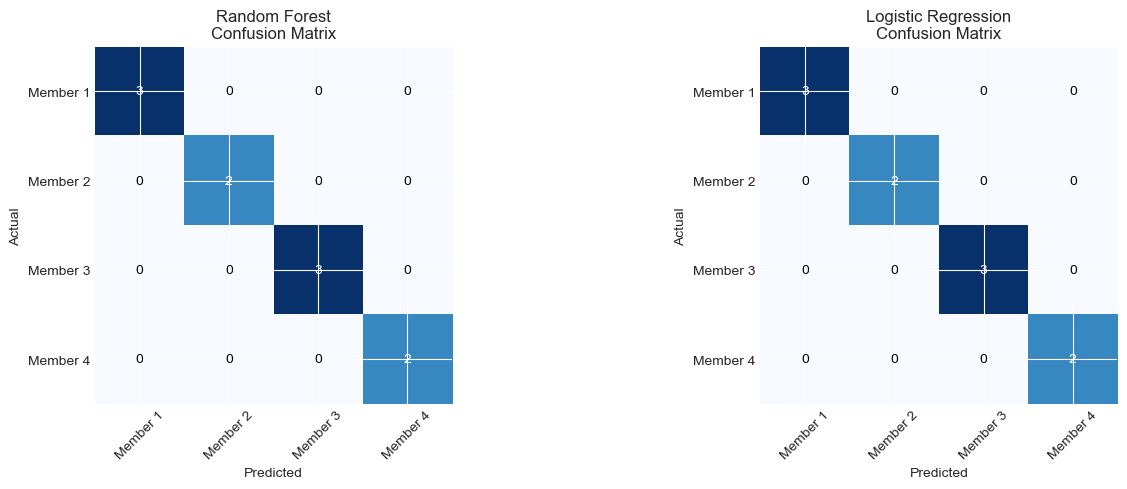

In [13]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
member_labels = [f'Member {i}' for i in sorted(np.unique(y))]

for ax, pred, name in [(axes[0], rf_pred, 'Random Forest'), (axes[1], lr_pred, 'Logistic Regression')]:
    cm = confusion_matrix(y_test, pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks(range(len(member_labels)))
    ax.set_yticks(range(len(member_labels)))
    ax.set_xticklabels(member_labels, rotation=45)
    ax.set_yticklabels(member_labels)
    
    # Add text annotations
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.savefig('outputs/face_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Model

Save the best-performing facial recognition model to `models/facial_recognition_model.pkl` for use in the CLI system simulation (Person 4).

In [14]:
import pickle

os.makedirs('models', exist_ok=True)
model_path = 'models/facial_recognition_model.pkl'

# Save best model along with metadata needed for prediction
model_bundle = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_columns': feature_cols,
    'authorized_members': sorted(np.unique(y).tolist()),
    'accuracy': rf_accuracy if best_model_name == 'Random Forest' else lr_accuracy,
    'f1_score': rf_f1 if best_model_name == 'Random Forest' else lr_f1,
}

with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)

print(f"Model saved: {model_path}")
print(f"Model type: {best_model_name}")
print(f"Authorized members: {model_bundle['authorized_members']}")
print(f"Accuracy: {model_bundle['accuracy']:.4f}")
print(f"F1-Score: {model_bundle['f1_score']:.4f}")

Model saved: models/facial_recognition_model.pkl
Model type: Random Forest
Authorized members: [1, 2, 3, 4]
Accuracy: 1.0000
F1-Score: 1.0000


## 8. Unauthorized Face Simulation Demo

Demonstrate how the model handles an unknown face (not in the training data). This simulates an unauthorized access attempt.

Unauthorized face image: 810x1080px


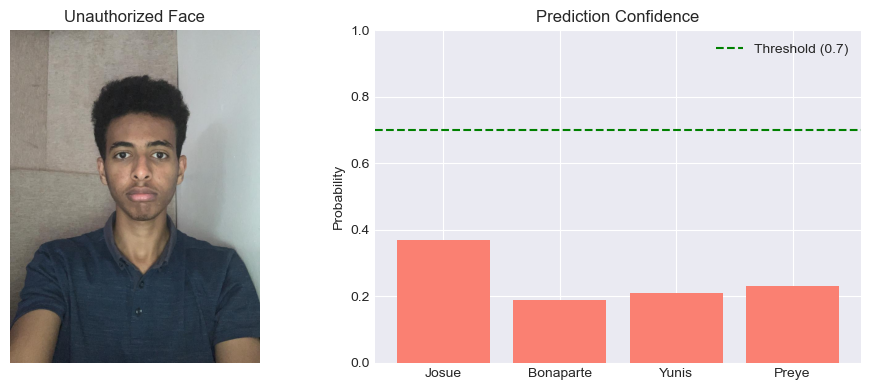


Predicted member: Josue
Max confidence: 0.3700
ACCESS DENIED - Confidence below threshold (unauthorized user detected)


In [15]:
# Load the unauthorized face image (a real person NOT in the group)
unauthorized_path = 'data/images/unauthorized_face.jpg'
unauthorized_cv = cv2.imread(unauthorized_path)

print(f"Unauthorized face image: {unauthorized_cv.shape[1]}x{unauthorized_cv.shape[0]}px")

# Extract features from unauthorized face
unauth_hist = extract_color_histogram(unauthorized_cv)
unauth_hog = extract_hog_features(unauthorized_cv)
unauth_features = np.array(unauth_hist + list(unauth_hog)).reshape(1, -1)

# Predict using the model
prediction = best_model.predict(unauth_features)[0]
confidence = best_model.predict_proba(unauth_features).max()

# Authorization logic: if max confidence is below threshold, deny access
CONFIDENCE_THRESHOLD = 0.7

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# Show unauthorized face
axes[0].imshow(cv2.cvtColor(unauthorized_cv, cv2.COLOR_BGR2RGB))
axes[0].set_title('Unauthorized Face', fontsize=12)
axes[0].axis('off')

# Show confidence distribution
proba = best_model.predict_proba(unauth_features)[0]
bars = axes[1].bar([f'{member_names[i]}' for i in sorted(np.unique(y))], proba, color='salmon')
axes[1].axhline(y=CONFIDENCE_THRESHOLD, color='green', linestyle='--', label=f'Threshold ({CONFIDENCE_THRESHOLD})')
axes[1].set_title('Prediction Confidence', fontsize=12)
axes[1].set_ylabel('Probability')
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('outputs/unauthorized_attempt.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPredicted member: {member_names.get(prediction, prediction)}")
print(f"Max confidence: {confidence:.4f}")
if confidence < CONFIDENCE_THRESHOLD:
    print("ACCESS DENIED - Confidence below threshold (unauthorized user detected)")
else:
    print(f"ACCESS GRANTED for {member_names.get(prediction, prediction)} (confidence: {confidence:.4f})")
    print("Note: In production, additional verification (voice) would follow")

## 9. Summary

### Task 2 Deliverables Complete:

| Deliverable | Status | Location |
|---|---|---|
| Image collection (4 members x 3 expressions) | Done | `data/images/member{N}/` |
| Image display grid | Done | `outputs/member_images_grid.png` |
| Augmentations (rotation, flip, grayscale) | Done | `data/images/augmented/` |
| Feature extraction (histograms + HOG) | Done | `image_features.csv` |
| `image_features.csv` | Done | `data/processed/image_features.csv` |
| Facial Recognition Model (trained) | Done | `models/facial_recognition_model.pkl` |
| Model evaluation (Accuracy, F1, Loss) | Done | See comparison table above |
| Unauthorized attempt demo | Done | `outputs/unauthorized_attempt.png` |

### Key Results:
- **48 total images** (12 original + 36 augmented)
- **2 models compared**: Random Forest vs Logistic Regression
- **Best model** saved with metadata for CLI integration
- **Unauthorized detection** via confidence thresholding